# Installing and importing modules

In [ ]:
import scipy.io as io
import numpy as np
import zipfile, io, os, sys
import pandas as pd

import requests, sys
import urllib.parse
from urllib.parse import urlencode

from google.colab import drive

import torch
from torch import nn
from torch.nn import init

from PIL import Image
from torch.utils.data import Dataset
import numpy as np
from skimage import data,img_as_float
from skimage.util import random_noise

import random
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

from scipy.interpolate import griddata
import glob
from tqdm import tqdm

In [ ]:
from google.colab import files as filescolab

In [ ]:
!pip install wandb -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.1/281.1 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.3 MB/s eta 0:00:00


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
#data.to(device=device, dtype=torch.float)

device(type='cuda')

In [ ]:
import wandb

wandb.login()


In [ ]:
def getZipDirs(zip_f, isRootDirOnly = False, addPath = True):
  dirs = []
  for f in zip_f.namelist():
    zinfo = zip_f.getinfo(f)
    if zinfo.is_dir():
      if isRootDirOnly:     # Only root directories:
        # This is will work in any OS because the zip format specifies a forward slash.
        r_dir = f.split('/')
        r_dir = r_dir[0]
        if r_dir not in dirs:
          dirs.append(r_dir)
      else: # All directories:
          dirs.append(f)
  if addPath:
    for dir in dirs:
      sys.path.append(os.path.abspath('/content/' + dir + "/"))
  return dirs

def loadTextFromYandexDisk(url: str, isZip = False):
  base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
  final_url = base_url + urlencode(dict(public_key=url))
  response = requests.get(final_url)
  download_url = response.json()['href']
  download_response = requests.get(download_url)

  if isZip:
    zip = zipfile.ZipFile(io.BytesIO(download_response.content))
    dirs = getZipDirs(zip, True)
    zip.extractall("/content/")
  else:
    download_response.encoding = download_response.apparent_encoding
    return download_response.text

In [ ]:
def eta_mol(T): #K-> Pa*s
    return -8.38278e-7+8.35717342e-8*T-7.69429583e-11*(T**2)+4.6437266E-14*(T**3)-1.06585607e-17*(T**4)

def Cp_det(T):
    return 1047.63657-0.372589265*T+9.45304214E-4*(T**2)-6.02409443E-7*(T**3)+1.2858961E-10*(T**4)

def rho_def(T, pA=1e5):
    R_const = 8.3145
    M_mol = 0.02897
    return pA*M_mol/R_const/T

def lam_mol(T):
    return -0.00227583562+1.15480022E-4*T-7.90252856E-8*(T**2)+4.11702505E-11*(T**3)-7.43864331E-15*(T**4)

In [ ]:
# constants
p0 = 1e5 # Pa
T0 = 22 #gradC

mu0 = 660
vr_0 = 0.06
p_0 = 0.013

l = 0.011 #m
v0 = 25 # m/s
Pr_t = 0.9
Tnorm = 465
rmin, rmax = 0, 0.15 #m
zmin, zmax = 0, 0.4 #m

Tref = T0 + 273.15

mu_mol = eta_mol(Tref) # Pa*s
lambda_mol = lam_mol(Tref) # W / m / gradC
Cp = Cp_det(Tref) #J / (kg * gradC)
rho0 = rho_def(Tref, pA=p0) # const rho

pres0 = rho_def(Tref, pA=p0) * (v0**2)

Re0 = rho0 * v0 * l / mu_mol
Pe0 = rho0 * Cp * v0 * l / lambda_mol

In [ ]:
# archive 320 * 128 simulation data (modified SA)
ref = "https://disk.yandex.ru/d/h3jgIp9PdyDMIg"

#archive 448 * 384 with T
#ref = 'https://disk.yandex.ru/d/9IfPBq6btNuOZA'

# archive 448*384 with N(r,z)
#ref = 'https://disk.yandex.ru/d/KE2txulz8FacAQ'

loadTextFromYandexDisk(ref, isZip=True)
#!rar x /content/200_data_archive/200_data.rar
#!unzip /content/content/data_tensors

In [ ]:
def d_dz(f, z):
    if z is None:
        dz = 1
    else:
        dz = z[0,0,1, 0] - z[0,0,0, 0]
    sobel = -0.125*torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]]).to(device) / dz

    filters = sobel.unsqueeze(0).unsqueeze(0)
    res = torch.nn.functional.conv2d(f.to(device), filters, padding='same', stride=1)
    res[:,:,0,:] = res[:,:,1,:]
    res[:,:,-1,:] = res[:,:,-2,:]
    return res

def d_dr(f, r):
    if r is None:
        dr = 1
    else:
        dr = r[0,0,0, -1] - r[0,0,0, -2]
    sobel = -0.125*torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]]).to(device) / dr
    filters = sobel.unsqueeze(0).unsqueeze(0)
    res = torch.nn.functional.conv2d(f.to(device), filters, padding='same', stride=1)

    res[:,:,:,0] = res[:,:,:,1]
    res[:,:,:,-1] = res[:,:,:,-2]
    return res

# Equations with numerical derivatives

In [ ]:
def pde_f1(out, T, N=320, M=128):

    # N-number of rows, Z-comp; M-number of columns, R-comp
    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')

    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

    VR = out[:, 0].unsqueeze(1) * vr_0
    VZ = out[:, 1].unsqueeze(1)

    rho = (T0 + 273.15) / (T*Tnorm + T0 + 273.15)

    ce_mem1 =  1 / r * d_dr(rho*r*VR, r)

    ce_mem1[:, :, :, 0] = 0

    ce_mem1[(torch.isinf(ce_mem1)) | (torch.isnan(ce_mem1))] = 0

    ce_mem2 =  d_dz(rho*VZ, z)
    ce_mem2[(torch.isinf(ce_mem2)) | (torch.isnan(ce_mem2))] = 0

    f1 = ce_mem1 + ce_mem2

    return f1

In [ ]:
def pde_f2(out, T, N=320, M=128):

    # N-number of rows, Z-comp; M-number of columns, R-comp

    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')
    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

    VR = out[:, 0].unsqueeze(1) * vr_0
    VZ = out[:, 1].unsqueeze(1)
    #T = out[:, 2].unsqueeze(1)
    P = out[:, 3].unsqueeze(1) * p_0
    mu = out[:, 4].unsqueeze(1)


    #derivatives
    VR_r = d_dr(VR, r)
    VR_z = d_dz(VR, z)
    VZ_r = d_dr(VZ, r)
    VZ_z = d_dz(VZ, z)
    P_r = d_dr(P, r)
    P_z = d_dz(P, z)

    T_r = d_dr(T, r)
    T_z = d_dz(T, z)
    mu_r = d_dr(mu, r)
    mu_z = d_dz(mu, z)

    rho = (T0 + 273.15) / (T*Tnorm + T0 + 273.15) # in equation

    # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
    div_v = 1 / r * d_dr(r * VR, r) + d_dz(VZ, z)
    div_v[(torch.isinf(div_v)) | (torch.isnan(div_v))] = 0

    # NS equation, r-projection
    # rho * (u * d_u/d_r + w * d_u/d_z)
    nsr_mem1 = rho * (VR * VR_r + VZ * VR_z)
    #-d_p/d_r
    nsr_mem2 = - P_r
    # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*u_r))/d_r)
    nsr_mem3 = mu0 * 1/Re0 * d_dr((mu+eta_mol(T * Tnorm+Tref)/eta_mol(Tref)/mu0)*(-2/3*div_v + 2*VR_r), r)
    # 1/Re0 * d_(mu * (u_z + w_r))/d_z
    nsr_mem4 = mu0 * 1/Re0 * d_dz((mu+eta_mol(T * Tnorm+Tref)/eta_mol(Tref)/mu0)*(VR_z + VZ_r), z)
    # 2/Re0 * mu/r * (u_r-u/r)
    nsr_mem5 = mu0 * 2/Re0 * (mu+eta_mol(T * Tnorm+Tref)/eta_mol(Tref)/mu0) / r * (VR_r - VR / r)

    f2 = nsr_mem1 - (nsr_mem2 + nsr_mem3 + nsr_mem4 + nsr_mem5)

    return f2

In [ ]:
def pde_f3(out, T, N=320, M=128):

    # N-number of rows, Z-comp; M-number of columns, R-comp

    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')
    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

    VR = out[:, 0].unsqueeze(1) * vr_0
    VZ = out[:, 1].unsqueeze(1)
    P = out[:, 3].unsqueeze(1) * p_0
    mu = out[:, 4].unsqueeze(1)


    rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

    lam = 1 + Cp * mu_mol / (Pr_t * lambda_mol) * (mu0*mu - 1)

    # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
    div_v = 1 / r * d_dr(r * VR, r) + d_dz(VZ, z)
    div_v[(torch.isinf(div_v)) | (torch.isnan(div_v))] = 0

    VR_r = d_dr(VR, r)
    VR_z = d_dz(VR, z)
    VZ_r = d_dr(VZ, r)
    VZ_z = d_dz(VZ, z)
    P_r = d_dr(P, r)
    P_z = d_dz(P, z)
    T_r = d_dr(T, r)
    T_z = d_dz(T, z)
    mu_r = d_dr(mu, r)
    mu_z = d_dz(mu, z)

    # NS equation, z-projection
    # rho * (u * d_w/d_r + w * d_w/d_z)
    nsz_mem1 = rho * (VR * VZ_r + VZ * VZ_z)
    #-d_p/d_z
    nsz_mem2 = - P_z
    # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*w_z))/d_z)
    nsz_mem3 = mu0 * 1/Re0 * d_dz((mu+eta_mol(T * Tnorm+Tref)/eta_mol(Tref)/mu0)*(-2/3*div_v + 2*VZ_z), z)
    # 1/Re0 * d_(mu * (w_r + u_z))/d_r
    nsz_mem4 = mu0 * 1/Re0 * d_dr((mu+eta_mol(T * Tnorm+Tref)/eta_mol(Tref)/mu0)*(VZ_r + VR_z), r)
    # 1/Re0 * mu / r * (u_z+w_r)
    nsz_mem5 = mu0 * 1/Re0 * (mu+eta_mol(T * Tnorm+Tref)/mu0/eta_mol(Tref)) / r * (VR_z + VZ_r)
    nsz_mem5[:,0,:, 0] = nsz_mem5[0,0,:, 0] * 0
    #nsz_mem5[(torch.isinf(nsz_mem5)) | (torch.isnan(nsz_mem5))] = 0

    f3 = nsz_mem1 - (nsz_mem2 + nsz_mem3 + nsz_mem4 + nsz_mem5)

    return f3

In [ ]:
def pde_f4(out, T, N=320, M=128):

    # N-number of rows, Z-comp; M-number of columns, R-comp

    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')
    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

    VR = out[:, 0].unsqueeze(1) * vr_0
    VZ = out[:, 1].unsqueeze(1)
    #T = out[:, 2].unsqueeze(1)
    P = out[:, 3].unsqueeze(1) * p_0
    mu = out[:, 4].unsqueeze(1)

    #derivatives
    VR_r = d_dr(VR, r)
    VR_z = d_dz(VR, z)
    VZ_r = d_dr(VZ, r)
    VZ_z = d_dz(VZ, z)
    P_r = d_dr(P, r)
    P_z = d_dz(P, z)

    T_r = d_dr(T, r)
    T_z = d_dz(T, z)
    mu_r = d_dr(mu, r)
    mu_z = d_dz(mu, z)

    rho = (T0 + 273.15) / (T*Tnorm + T0 + 273.15) # in equation

    lam = 1 + Cp * mu_mol / (Pr_t * lambda_mol) * mu0*mu

    #energy equation
    #rho*(u*d_T/d_r + w*d_T/d_z)
    en_eq_mem1 = rho * (VR * T_r + VZ * T_z)
    #1/Pe0 * 1 / r * d_(lambda_*r*T_r)/dr
    en_eq_mem2 = 1/Pe0 * 1 / r * d_dr(lam*r*T_r, r)
    en_eq_mem2[0,0,:,0] = en_eq_mem2[0,0,:,0]*0
    #en_eq_mem2[(torch.isinf(en_eq_mem2)) | (torch.isnan(en_eq_mem2))] = 0
    #1/Pe0 * d_(lambda_*T_z)/dz
    en_eq_mem3 = 1/Pe0 * d_dz(lam*T_z, z)

    f4 = en_eq_mem1 - (en_eq_mem2 + en_eq_mem3)


    return f4

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MakeDataset(Dataset):
    def __init__(
        self,
        transform=None,
        data=None,
        N = 320,
        M = 128,
        num=-1
    ):
        self.loaded_images = torch.zeros(0, 5,  N, M)
        self.Tnorm = torch.zeros((0,1))
        self.num=num

        files = glob.glob('/content/data_tensors/content/data_tensors/tensors/*.pt')
        if self.num == -1:
            self.num = len(files)
        for filename in tqdm(files[:self.num]):
            z = torch.load(filename)
            self.loaded_images = torch.cat((self.loaded_images, z.unsqueeze(0)))

    def normalize(self, data_n):
        #u, v, T, p, mu
        data_n[0] = data_n[0]/ v0 / vr_0
        data_n[1] = data_n[1] / v0
        data_n[2] = data_n[2] / Tnorm
        data_n[3] = data_n[3] / pres0 / p_0
        data_n[4] = data_n[4] * eta_mol(data_n[2]*Tnorm+Tref) / mu_mol / mu0
        return data_n


    def __getitem__(self, i):
        img = self.loaded_images[i].numpy()
        img = self.normalize(img)

        return img

    def __len__(self):
        return len(self.loaded_images)

In [ ]:
trainset = MakeDataset()

100%|██████████| 308/308 [00:31<00:00,  9.92it/s]


In [ ]:
bs = 16

train_loader = DataLoader(trainset, batch_size=bs, shuffle=True, num_workers=2)
len(train_loader)

20

In [ ]:
simFields = next(iter(train_loader))

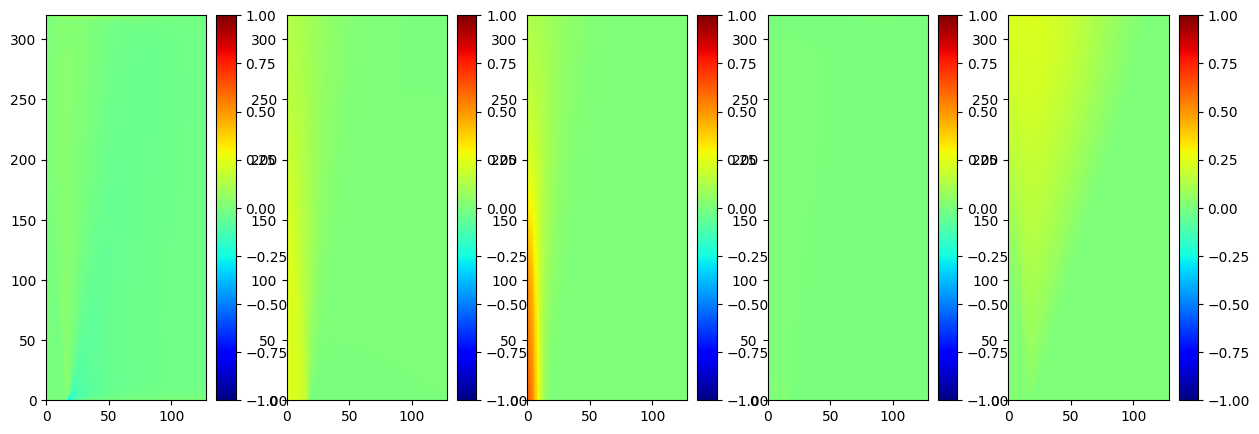

In [ ]:
simFields = next(iter(train_loader))
idx=5

fig, ax = plt.subplots(1,5, figsize=(15, 5))

for i in range(5):
    im = ax[i].pcolor(simFields[idx, i], cmap='jet', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax[i])

plt.show()

# SimpleAE model

In [ ]:
import torch.nn.functional as F

class simpleAE(nn.Module):
  def __init__(self, latent_dim=2):
    super().__init__()

    hidden_dims_e = [32, 64, 128, 256]
    modules_encoder = []
    in_channels = 1

    for h_dim in hidden_dims_e:
      modules_encoder.append(
          nn.Sequential(
              nn.Conv2d(
                  in_channels=in_channels,
                  out_channels=h_dim,
                  kernel_size=3,
                  stride=2,
                  padding=1,
              ),
              nn.BatchNorm2d(h_dim),
              nn.Tanh(),
          )
      )
      in_channels = h_dim

    modules_encoder.append(nn.Flatten())
    modules_encoder.append(nn.Linear(256*20*8, latent_dim))

    self.encoder = nn.Sequential(*modules_encoder)

    modules_decoder = []
    hidden_dims = [256, 128, 64, 32]
    self.linear = nn.Linear(in_features=latent_dim, out_features =256*20*8)

    for i in range(len(hidden_dims) - 1):
        modules_decoder.append(
            nn.Sequential(
                nn.Upsample(scale_factor=2),
                nn.Conv2d(
                    in_channels=hidden_dims[i],
                    out_channels=hidden_dims[i + 1],
                    kernel_size=3,
                    padding='same',
                ),
                nn.BatchNorm2d(hidden_dims[i + 1]),
                nn.Tanh(),
            )
        )

    modules_decoder.append(
        nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels=hidden_dims[-1], out_channels=5, kernel_size=1),
        )
    )

    self.decoder = nn.Sequential(*modules_decoder)

  def forward(self, x):
    x = self.encoder(x)
    x = self.linear(x)  # from latents space to Linear
    x = x.view(-1, 256, 20, 8)  # reshape
    x = self.decoder(x)  # reconstruction
    x = F.tanh(x)
    return x

In [ ]:
from torchsummary import summary

latent_dim = 4

ae = simpleAE(latent_dim=latent_dim)
print(">>> Encoder")
print(summary(ae, (1, 320, 128), device="cpu"))

>>> Encoder
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 32, 160, 64]             320
       BatchNorm2d-2          [-1, 32, 160, 64]              64
              Tanh-3          [-1, 32, 160, 64]               0
            Conv2d-4           [-1, 64, 80, 32]          18,496
       BatchNorm2d-5           [-1, 64, 80, 32]             128
              Tanh-6           [-1, 64, 80, 32]               0
            Conv2d-7          [-1, 128, 40, 16]          73,856
       BatchNorm2d-8          [-1, 128, 40, 16]             256
              Tanh-9          [-1, 128, 40, 16]               0
           Conv2d-10           [-1, 256, 20, 8]         295,168
      BatchNorm2d-11           [-1, 256, 20, 8]             512
             Tanh-12           [-1, 256, 20, 8]               0
          Flatten-13                [-1, 40960]               0
           Linear-14       

In [ ]:
class Metrics_ac():
    def __init__(self):

        self.NRMSE_mean = lambda x, y: \
                    torch.sqrt(torch.mean(torch.pow(x-y, 2)))/ \
                    torch.abs(torch.mean(y))
        self.NRMSE_max = lambda x, y: \
                    torch.sqrt(torch.mean(torch.pow(x-y, 2)))/ \
                    torch.abs(torch.max(y))
        self.preds = []
        self.targets = []

    def calculate(self, pred, target):
        bs = pred.shape[0]
        mean_m, max_m = torch.zeros(bs), torch.zeros(bs)
        for j, (pred, target) in enumerate(zip(pred,  target)):
            for i, (p, t) in enumerate(zip(pred, target)):
                mean_m[i] = self.NRMSE_mean(p.float(), t.float())
                max_m[i] = self.NRMSE_max(p.float(), t.float())
        return torch.mean(mean_m), torch.mean(max_m)

In [ ]:
wandb.init(
        settings=wandb.Settings(start_method="thread"),
        project="DAE_PDE_simple_AE_v1",
        config={
            "lr": 1e-3,
            "comment": 'latent dim=4, only data'
            })

wandb: Currently logged in as: ykrudenko. Use `wandb login --relogin` to force relogin


In [ ]:
!pip install -q lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 57.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.2/802.2 kB 21.6 MB/s eta 0:00:00


In [ ]:
import lightning as L


In [ ]:
def loss_derivatives(out, tar, metric, N=320, M=128):
    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')
    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

    return metric(d_dr(out, r), d_dr(tar,r))+metric(d_dz(out, z), d_dz(tar,z))

In [ ]:
def loss_derivatives_smooth(out, metric, N=320, M=128):
    eps = 1e-6
    r = torch.linspace(rmin+eps, rmax, M) / l
    z = torch.linspace(zmin, zmax, N) / l

    r, z = torch.meshgrid(r, z, indexing='xy')
    r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
    ders = torch.sqrt(d_dr(out, r) **2 + d_dz(out, z)**2)
    res = metric(ders.max()*0.3, ders.mean())

    return res

In [ ]:
from torch.nn import MSELoss
from lightning.pytorch.callbacks import ModelCheckpoint

class Lit_test1(L.LightningModule):
    def __init__(self, model, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.model = model
        self.metric = nn.L1Loss()
        self.metric_ders = torch.nn.MSELoss()
        self.train_acc = Metrics_ac()
        self.lr=lr

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(), lr=self.lr*0.01)
        return optimizer

    def training_step(self, batch, batch_idx):

        train_inputs = batch[:, 2,:,:].unsqueeze(1)

        train_outputs = self.model(train_inputs)

        loss_data_vr = self.metric(train_outputs[:,0], batch[:,0])
        loss_data_vz = self.metric(train_outputs[:,1], batch[:,1])
        loss_data_T = self.metric(train_outputs[:,2], batch[:,2])
        loss_data_p = self.metric(train_outputs[:,3], batch[:,3])
        loss_data_muT = self.metric(train_outputs[:,4], batch[:,4])

        loss_ders_vr = loss_derivatives(train_outputs[:,0].unsqueeze(1),
                                        batch[:,0].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_vz = loss_derivatives(train_outputs[:,1].unsqueeze(1),
                                        batch[:,1].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_T = loss_derivatives(train_outputs[:,2].unsqueeze(1),
                                       batch[:,2].unsqueeze(1),
                                       self.metric_ders)
        loss_ders_p = loss_derivatives(train_outputs[:,3].unsqueeze(1),
                                       batch[:,3].unsqueeze(1),
                                       self.metric_ders)
        loss_ders_mu = loss_derivatives(train_outputs[:,4].unsqueeze(1),
                                        batch[:,4].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_vr_smooth = loss_derivatives_smooth(train_outputs[:,0].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_vz_smooth = loss_derivatives_smooth(train_outputs[:,1].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_p_smooth = loss_derivatives_smooth(train_outputs[:,3].unsqueeze(1),
                                        self.metric_ders)
        loss_ders_mu_smooth = loss_derivatives_smooth(train_outputs[:,4].unsqueeze(1),
                                        self.metric_ders)
        loss=loss_data_vr+loss_data_vz+loss_data_p+loss_data_muT+loss_data_T+\
             loss_ders_vr+loss_ders_vz+loss_ders_T+loss_ders_p+loss_ders_mu+\
             loss_ders_vr_smooth+loss_ders_vz_smooth+\
             loss_ders_p_smooth+loss_ders_mu_smooth

        metrics = {'loss_data_vr': loss_data_vr,
                   'loss_data_vz': loss_data_vz,
                   'loss_data_T': loss_data_T,
                   'loss_data_p': loss_data_p,
                   'loss_data_muT': loss_data_muT,
                   'loss_ders_vr': loss_ders_vr,
                   'loss_ders_T': loss_ders_T,
                   'loss_ders_vz': loss_ders_vz,
                   'loss_ders_p': loss_ders_p,
                   'loss_ders_mu': loss_ders_mu,
                   'loss_ders_vr_smooth': loss_ders_vr_smooth,
                   'loss_ders_vz_smooth': loss_ders_vz_smooth,
                   'loss_ders_p_smooth': loss_ders_p_smooth,
                   'loss_ders_mu_smooth': loss_ders_mu_smooth,
                   'loss': loss
                   }

        acc_metrics = dict()

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,0].unsqueeze(1), batch[:,0].unsqueeze(1))
        acc_metrics['vr_mean'], acc_metrics['vr_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,1].unsqueeze(1), batch[:,1].unsqueeze(1))
        acc_metrics['vz_mean'], acc_metrics['vz_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,2].unsqueeze(1), batch[:,2].unsqueeze(1))
        acc_metrics['T_mean'], acc_metrics['T_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,3].unsqueeze(1), batch[:,3].unsqueeze(1))
        acc_metrics['p_mean'], acc_metrics['p_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,4].unsqueeze(1), batch[:,4].unsqueeze(1))
        acc_metrics['muT_mean'], acc_metrics['muT_max'] = mean_m, max_m

        wandb.log(metrics)
        wandb.log(acc_metrics)

        self.log('loss', loss)

        return loss

    def validation_step(self, batch, batch_idx):
      pass


    def on_train_epoch_end(self):
      pass


    def on_validation_epoch_end(self):
        pass

    def forward(self, x):
      return self.model(x)


In [ ]:
model = simpleAE(latent_dim=4)

In [ ]:
num_epochs = 205
L.seed_everything(42)

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename='simpleDAE-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    verbose=True,
    monitor="loss",
    mode="min")

path='/content/checkpoints/simpleDAE-epoch=94-val_loss=0.00.ckpt'
if path:
  lit_model = Lit_test1.load_from_checkpoint(checkpoint_path=path)
else:
  lit_model = Lit_test1(model)

trainer_u = L.Trainer(max_epochs=num_epochs,
                      callbacks=[checkpoint_callback])

trainer_u.fit(model=lit_model, train_dataloaders=train_loader,
              )

#wandb.finish()

saving weights of the model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
filename='simple_dae_model_w_ld=4_best.pt'
torch.save(model.state_dict(), filename)
filescolab.download(filename)

# loading weights of the model

In [ ]:
ref='https://disk.yandex.ru/d/M_TeA3fFWX2p2w'
loadTextFromYandexDisk(ref, isZip=True)

In [ ]:
path='/content/ld=4/simpleDAE-epoch=94-val_loss=0.00-v1.ckpt'
modelTest = simpleAE(latent_dim=4)
#lt = Lit_test1(modelTest)
lit_model_best = Lit_test1.load_from_checkpoint(checkpoint_path=path)

#model.eval()

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


# Predicting on simulation data

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


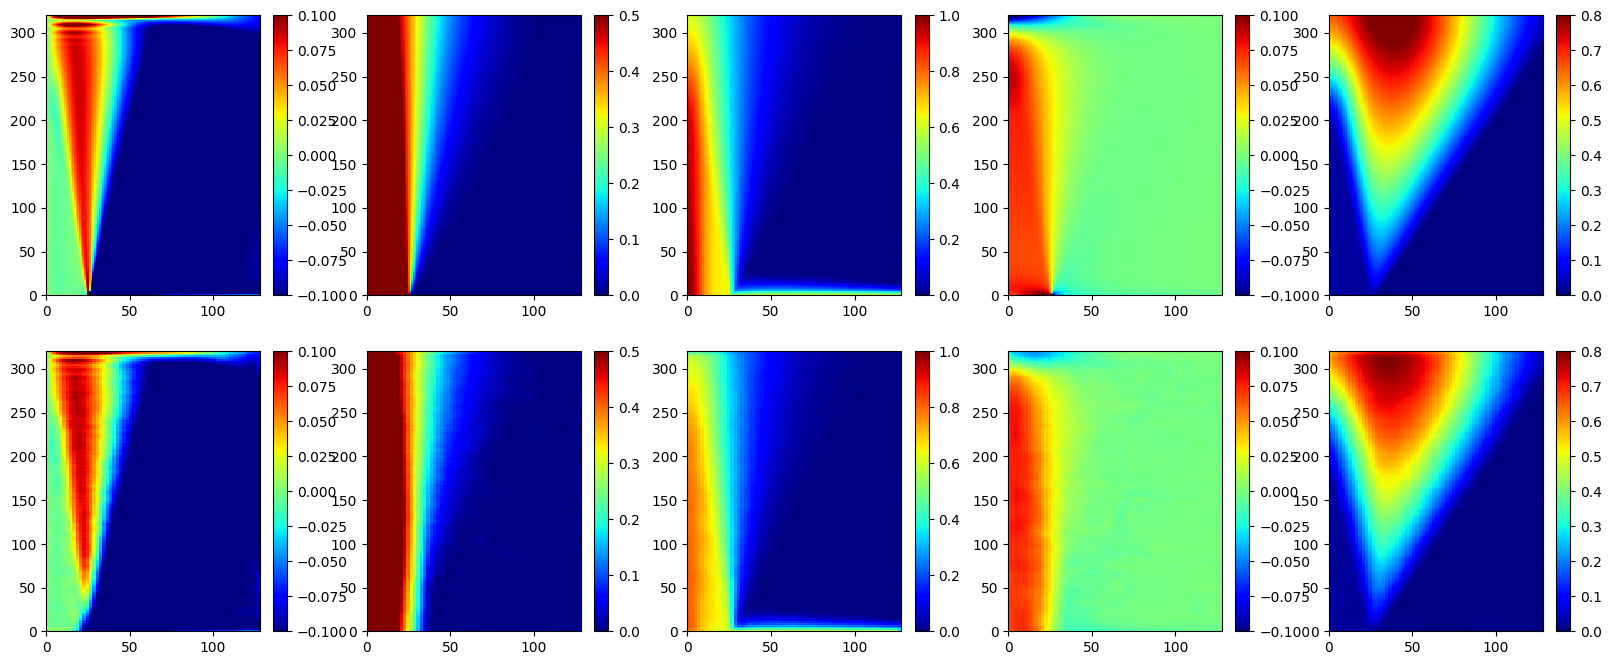

In [ ]:
im = next(iter(train_loader))

train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
#model = lit_model.to(device)
lit_model_best.to(device)
out = lit_model_best(train_inputs)

idx=1

cax = [(-0.1, 0.1), (0, 0.5), (0, 1), (-0.1, 0.1), (0, 0.8)]
fig, ax = plt.subplots(2, 5, figsize=(20, 8))

for i in range(5):
  im_tar = ax[0, i].pcolor(im[idx,i].detach().cpu().numpy(), cmap='jet', vmin=cax[i][0], vmax=cax[i][1])
  plt.colorbar(im_tar, ax=ax[0, i])

  im_pred = ax[1, i].pcolor(out[idx,i].detach().cpu().numpy(), cmap='jet', vmin=cax[i][0], vmax=cax[i][1])
  plt.colorbar(im_pred, ax=ax[1, i])

plt.show()

# Checking residuals

In [ ]:
im = next(iter(train_loader))
im = im.to(device)

In [ ]:
train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
lit_model_best = lit_model_best.to(device)
train_outputs = lit_model_best(train_inputs)

pde_T = train_outputs[:, 2,:,:].unsqueeze(1)
pde_T = pde_T.to(device)

f1 = pde_f1(train_outputs, train_inputs)
f2 = pde_f2(train_outputs, train_inputs)
f3 = pde_f3(train_outputs, train_inputs)
f4 = pde_f4(train_outputs, train_inputs)

f1_sim = pde_f1(im, pde_T)
f2_sim = pde_f2(im, pde_T)
f3_sim = pde_f3(im, pde_T)
f4_sim = pde_f4(im, pde_T)

In [ ]:
f1.shape

torch.Size([16, 1, 320, 128])

res_sim_max tensor(0.3303)
res_model_max tensor(0.1181)
res_sim_max tensor(0.1975)
res_model_max tensor(4312.0781)
res_sim_max tensor(0.2974)
res_model_max tensor(0.3572)
res_sim_max tensor(11.0720)
res_model_max tensor(15.5089)


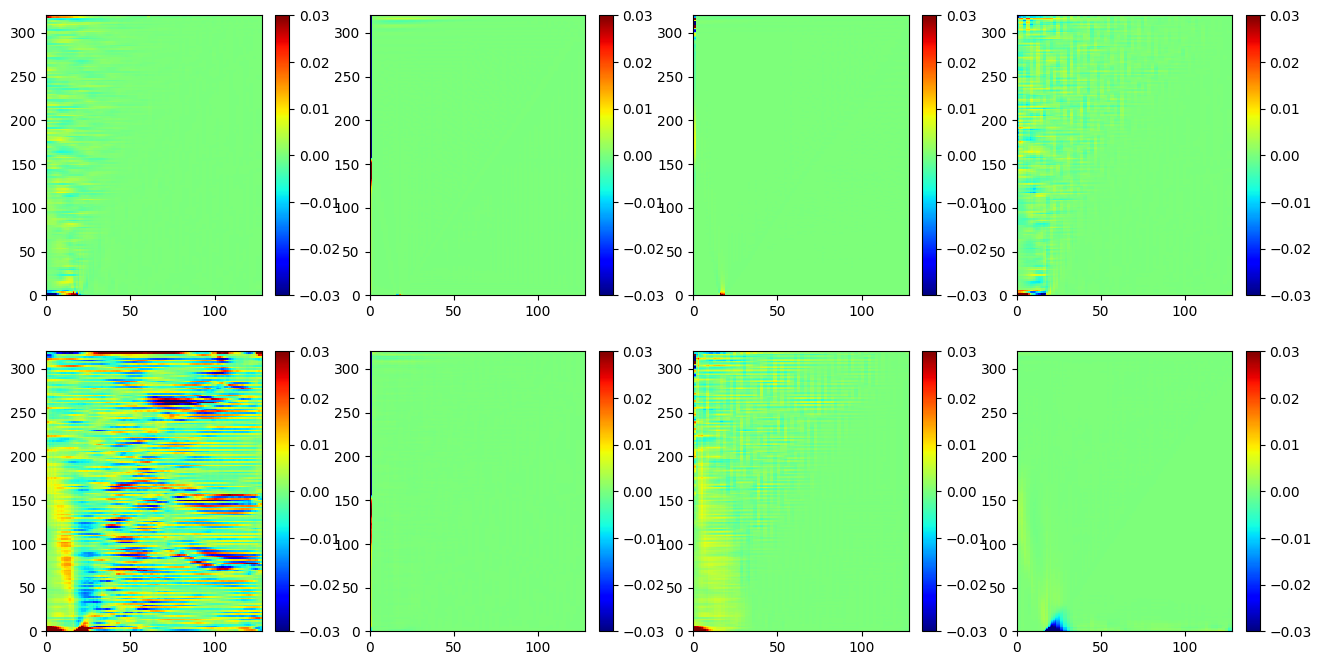

In [ ]:
idx = 2

fig, ax = plt.subplots(2,4, figsize=(16, 8))

resid_model = [f1,f2,f3,f4]
resid_sim = [f1_sim,f2_sim,f3_sim,f4_sim]
lim0 = 0.03
for i in range(4):
  im_tar = ax[0,i].pcolor(resid_sim[i][idx,0].detach().cpu().numpy(),
                           cmap='jet', vmin=-lim0, vmax=lim0)
  plt.colorbar(im_tar, ax=ax[0,i])
  print(f'res_sim_max', resid_sim[i][idx,0].detach().cpu().max())

  im_tar = ax[1,i].pcolor(resid_model[i][idx,0].detach().cpu().numpy(),
                           cmap='jet', vmin=-lim0, vmax=lim0)
  print(f'res_model_max', resid_model[i][idx,0].detach().cpu().max())
  plt.colorbar(im_tar, ax=ax[1,i])

plt.show()

#2. Turn on the physics loss (residuals from equations)

In [ ]:
def q1q2(mask, f):
  q1 = torch.quantile(torch.abs(f[mask]), 0.1)
  q2 = torch.quantile(torch.abs(f[mask]), 0.9)
  q1q2mask = torch.where((torch.abs(f[mask]) > q1) & \
          ((torch.abs(f[mask]) < q2)))
  res = torch.abs(f[mask])[q1q2mask].max()
  return res

In [ ]:
def loss_inlet_f(metricL2, out,tar):
  loss_inlet = metricL2(out[:,0,0,:], torch.zeros_like(out[:,0,0,:]))+\
                metricL2(out[:,1,0,:], tar[:,1,0,:])+\
                metricL2(out[:,2,0,:], tar[:,2,0,:])+\
                metricL2(out[:,4,0,:], tar[:,4,0,:])
                #metricL2(out[:,3,0,:], tar[:,3,0,:])+\

  return loss_inlet

In [ ]:
def loss_axis_f(metricL2, out,tar):

  loss_ax= metricL2(out[:,0,:,0], torch.zeros_like(out[:,0,:,0]))+\
                metricL2(out[:,1,:,0], out[:,1,:,-1])+\
                metricL2(out[:,2,:,0], tar[:,2,:,0])+\
                metricL2(out[:,3,:,0], out[:,3,:,-1])+\
                metricL2(out[:,4,:,0], out[:,4,:,-1])
  return loss_ax

In [ ]:
def loss_outlet_f(metricL2, out,tar):
  loss_out =  metricL2(out[:,3,-1,:], torch.zeros_like(out[:,3,-1,:]))+\
              metricL2(out[:,2,-1,:], tar[:,2,-1,:])
              #metricL2(out[:,0,-1,:], tar[:,0,-1,:])+\
             #   metricL2(out[:,1,-1,:], tar[:,1,-1,:])+\
             #   metricL2(out[:,2,-1,:], tar[:,2,-1,:])+\
             #   metricL2(out[:,4,-1,:], tar[:,4,-1,:])
  return loss_out

In [ ]:
def loss_free_f(metricL2, out, tar):
  loss_free =  metricL2(out[:,2,:,-1], tar[:,2,:,-1])+\
               metricL2(out[:,1,:,-1], torch.zeros_like(out[:,1,:,-1]))+\
               metricL2(out[:,3,:,-1], out[:,3,:,-2])+\
               metricL2(out[:,4,:,-1], torch.ones_like(out[:,4,:,-1])*1/mu0)
  return loss_free

# Сhecking the smoothness of derivatives

In [ ]:
N=320
M=128

r = torch.linspace(rmin+1e-10, rmax, M) / l
z = torch.linspace(zmin, zmax, N) / l

r, z = torch.meshgrid(r, z, indexing='xy')
r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

VZ = out[:, 4].unsqueeze(1)


VZ_r = d_dr(VZ, r)
VZ_z = d_dz(VZ, z)

sum_q = torch.sqrt(VZ_r ** 2+VZ_z**2)

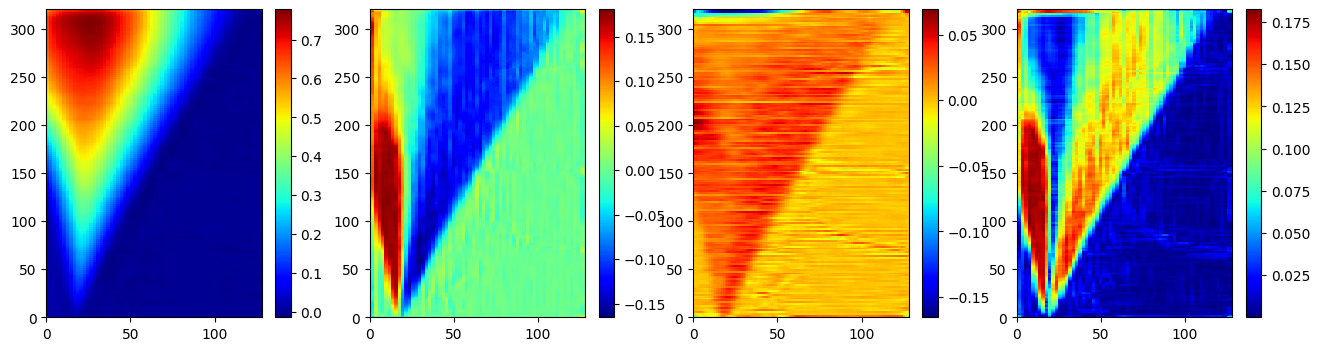

In [ ]:
fig,ax=plt.subplots(1,4, figsize=(16,4))

idx=4
im_tar = ax[0].pcolor(VZ[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[0])

im_tar = ax[1].pcolor(VZ_r[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[1])

im_tar = ax[2].pcolor(VZ_z[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[2])

im_tar = ax[3].pcolor(sum_q[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[3])

plt.show()

In [ ]:
sum_q_np=sum_q[idx,0].detach().cpu().numpy()
print(f'max: {sum_q_np.max()}',
      f'median: {np.median(sum_q_np)}',
      f'mean: {sum_q_np.mean()}')

max: 0.182451993227005 median: 0.026635203510522842 mean: 0.05543044954538345


In [ ]:
N=320
M=128

r = torch.linspace(rmin+1e-10, rmax, M) / l
z = torch.linspace(zmin, zmax, N) / l

r, z = torch.meshgrid(r, z, indexing='xy')
r=r.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)
z=z.unsqueeze(0).unsqueeze(0).expand(out.shape[0], 1, out.shape[2], out.shape[3]).to(device)

VZ = im[:, 1].unsqueeze(1)


VZ_r = d_dr(VZ, r)
VZ_z = d_dz(VZ, z)

sum_q = torch.sqrt(VZ_r ** 2+VZ_z**2)

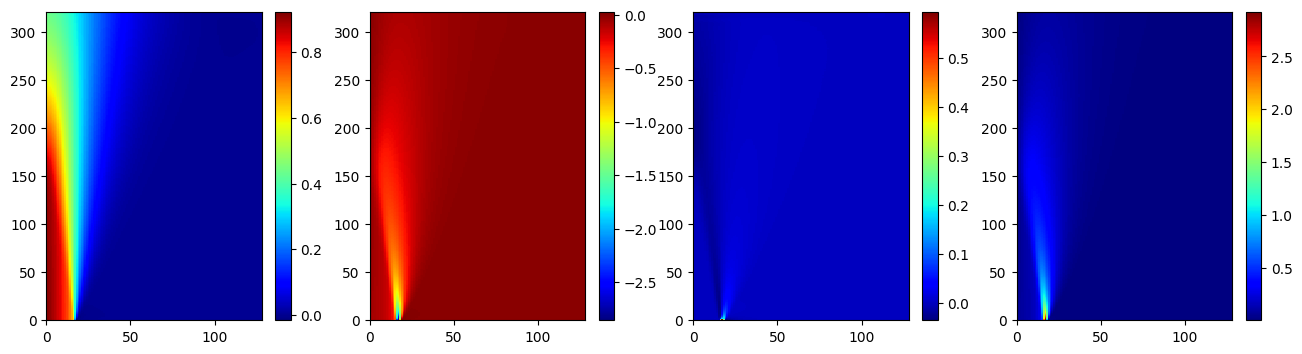

In [ ]:
fig,ax=plt.subplots(1,4, figsize=(16,4))

idx=2
im_tar = ax[0].pcolor(VZ[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[0])

im_tar = ax[1].pcolor(VZ_r[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[1])

im_tar = ax[2].pcolor(VZ_z[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[2])

im_tar = ax[3].pcolor(sum_q[idx,0].detach().cpu().numpy(), cmap='jet')
plt.colorbar(im_tar,ax=ax[3])

plt.show()

In [ ]:
sum_q_np=sum_q[idx,0].detach().cpu().numpy()
print(f'max: {sum_q_np.max()}',
      f'median: {np.median(sum_q_np)}',
      f'mean: {sum_q_np.mean()}')

max: 2.918626308441162 median: 0.0029223551973700523 mean: 0.05576642230153084


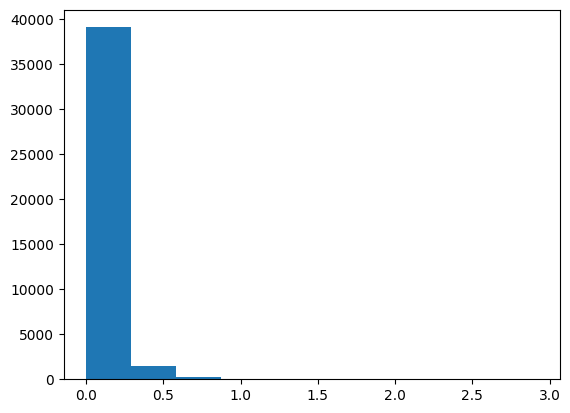

In [ ]:
plt.hist(sum_q_np.flatten())
plt.show()

# Residuals

In [ ]:
im = next(iter(train_loader))
im = im.to(device)

In [ ]:
train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
lit_model = lit_model.to(device)
train_outputs = lit_model(train_inputs)

pde_T = train_outputs[:, 2,:,:].unsqueeze(1)
pde_T = pde_T.to(device)

f1 = pde_f1(train_outputs, train_inputs)
f2 = pde_f2(train_outputs, train_inputs)
f3 = pde_f3(train_outputs, train_inputs)
f4 = pde_f4(train_outputs, train_inputs)

f1_sim = pde_f1(im, pde_T)
f2_sim = pde_f2(im, pde_T)
f3_sim = pde_f3(im, pde_T)
f4_sim = pde_f4(im, pde_T)

res_sim_max tensor(0.3079)
res_model_max tensor(0.1297)
res_sim_max tensor(0.1241)
res_model_max tensor(4459.8628)
res_sim_max tensor(0.3107)
res_model_max tensor(0.4042)
res_sim_max tensor(9.9909)
res_model_max tensor(15.3208)


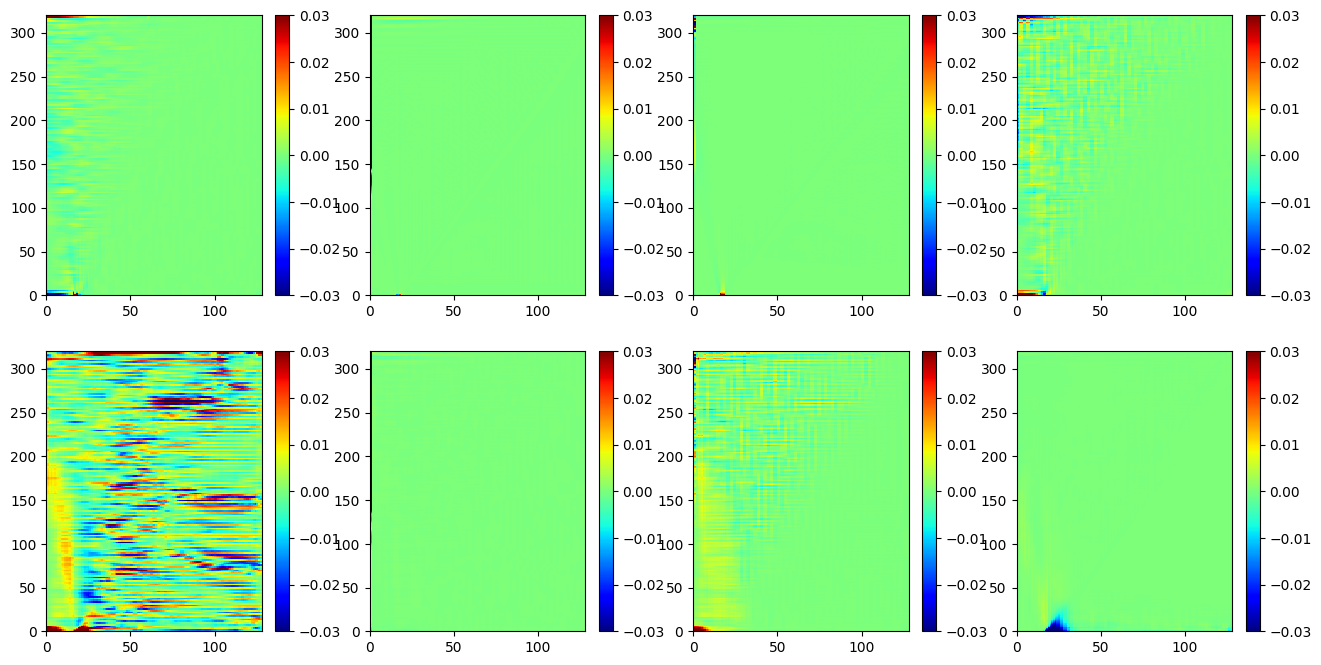

In [ ]:
idx = 2

fig, ax = plt.subplots(2,4, figsize=(16, 8))

resid_model = [f1,f2,f3,f4]
resid_sim = [f1_sim,f2_sim,f3_sim,f4_sim]
lim0 = 0.03
for i in range(4):
  im_tar = ax[0,i].pcolor(resid_sim[i][idx,0].detach().cpu().numpy(),
                           cmap='jet', vmin=-lim0, vmax=lim0)
  plt.colorbar(im_tar, ax=ax[0,i])
  print(f'res_sim_max', resid_sim[i][idx,0].detach().cpu().max())

  im_tar = ax[1,i].pcolor(resid_model[i][idx,0].detach().cpu().numpy(),
                           cmap='jet', vmin=-lim0, vmax=lim0)
  print(f'res_model_max', resid_model[i][idx,0].detach().cpu().max())
  plt.colorbar(im_tar, ax=ax[1,i])

plt.show()

# First variant for mask with temeperature threshold

In [ ]:
mask = (train_inputs[:,0] >= train_inputs[:,0].max()*0.01).unsqueeze(1)
mask.shape

torch.Size([16, 1, 320, 128])

In [ ]:
(resid_model[0]*mask).shape

torch.Size([16, 1, 320, 128])

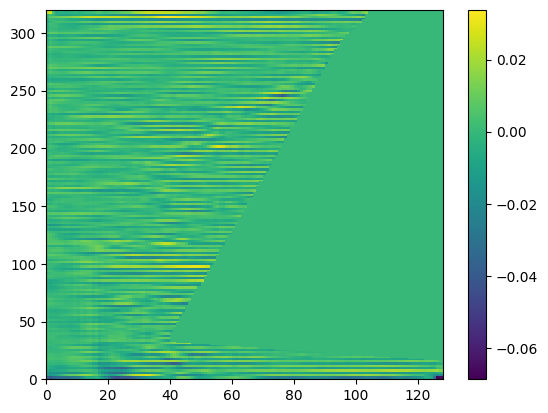

In [ ]:
#mask = (train_inputs[:,0] >= train_inputs[0,0].max()*0.01)
plt.pcolor((resid_model[0]*mask).detach().cpu()[0,0])
plt.colorbar()
plt.show()

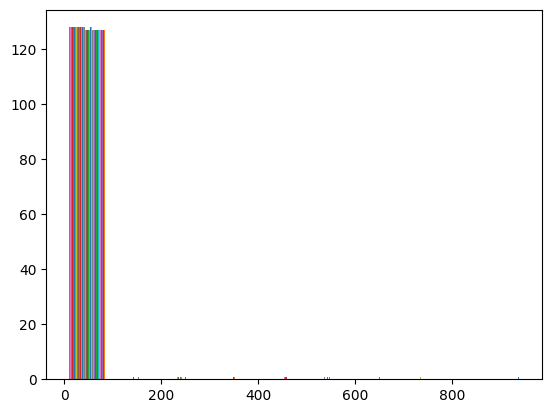

In [ ]:
plt.hist(torch.abs((resid_model[1]*mask))[0,0].detach().cpu())
plt.show()

In [ ]:
resid_model[idx][mask].shape

torch.Size([261620])

In [ ]:
idx = 3

q1 = torch.quantile(torch.abs(resid_model[idx][mask]), 0.1)
q2 = torch.quantile(torch.abs(resid_model[idx][mask]), 0.9)

In [ ]:
q2

tensor(0.0003, grad_fn=<SqueezeBackward4>)

In [ ]:
test = torch.where((torch.abs(resid_model[idx][mask]) > q1) & \
 ((torch.abs(resid_model[idx][mask]) < q2)))

torch.abs(resid_model[idx][mask])[test].mean()

tensor(4.1467e-05, grad_fn=<MeanBackward0>)

In [ ]:
resid_model[idx][:,0].max()

tensor(42.0068, grad_fn=<MaxBackward1>)

# Second variant for more coplex mask with problem areas

In [ ]:
im = next(iter(train_loader))
im = im.to(device)

In [ ]:
train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)

f1_sim = pde_f1(im, train_inputs)
f2_sim = pde_f2(im, train_inputs)
f3_sim = pde_f3(im, train_inputs)
f4_sim = pde_f4(im, train_inputs)

res_sim_max tensor(0.2948)
res_sim_max tensor(0.1662)
res_sim_max tensor(0.2458)
res_sim_max tensor(13.0437)


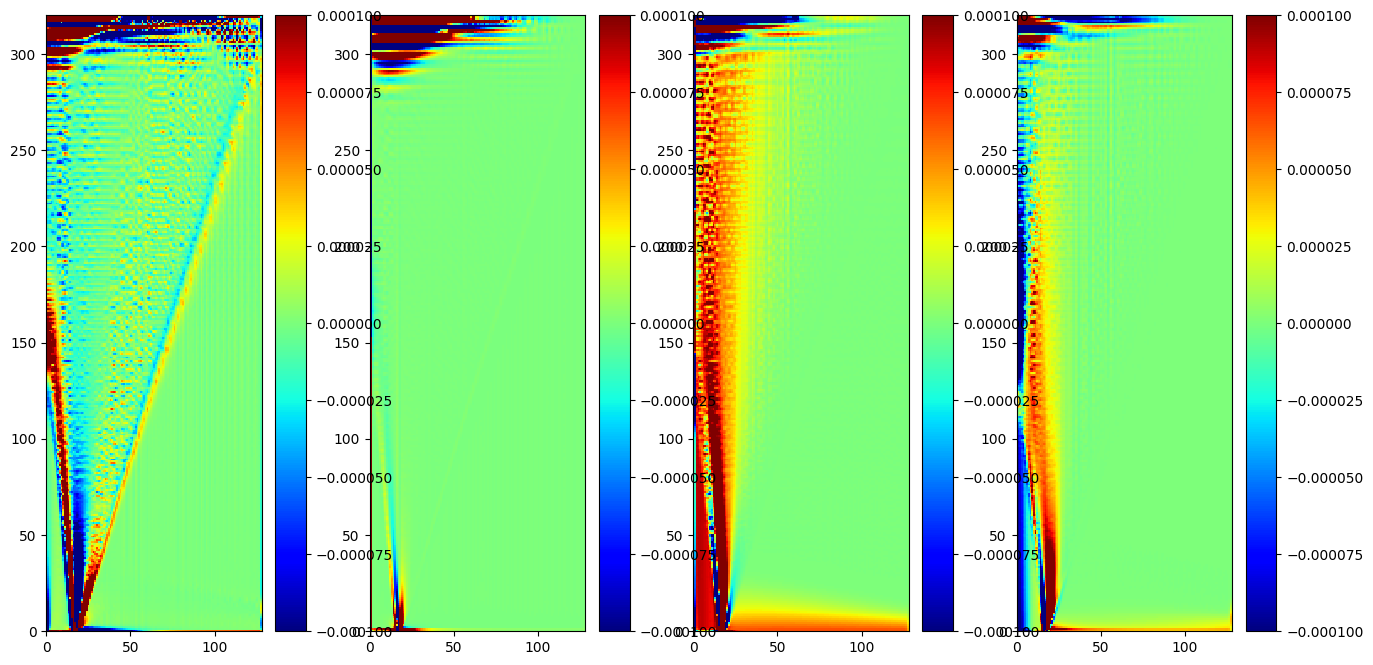

In [ ]:
idx = 2

fig, ax = plt.subplots(1,4, figsize=(16, 8))

resid_sim = [f1_sim,f2_sim,f3_sim,f4_sim]
lim0 = 0.0001
for i in range(4):
  im_tar = ax[i].pcolor(resid_sim[i][idx,0].detach().cpu().numpy(),
                           cmap='jet', vmin=-lim0, vmax=lim0)
  plt.colorbar(im_tar, ax=ax[i])
  print(f'res_sim_max', resid_sim[i][idx,0].detach().cpu().max())

plt.show()

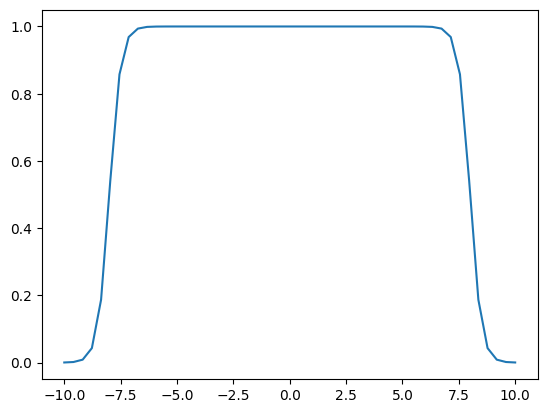

In [ ]:
r1 = np.linspace(-10,10)
y1 =(1-0)/2+ (1+0)/2*np.tanh((r1-r1.min()*0.8)/0.5)
y2 = (1-0)/2+ (1+0)/2*np.tanh(-(r1+r1.min()*0.8)/0.5)
plt.plot(r1, y1*y2)
#plt.plot(r1, y1)
#plt.plot(r1, y2)
plt.show()

In [ ]:
eps = 1e-6
N, M = 320,128
r = torch.linspace(rmin+eps, rmax, M) / l
z = torch.linspace(zmin, zmax, N) / l

r, z = torch.meshgrid(r, z, indexing='xy')
r=r.unsqueeze(0).unsqueeze(0).expand(im.shape[0], 1, im.shape[2], im.shape[3])
z=z.unsqueeze(0).unsqueeze(0).expand(im.shape[0], 1, im.shape[2], im.shape[3])
r=r[0,0]
z=z[0,0]

mask1 = (1-0)/2+ (1+0)/2*np.tanh((r*1-r.max()*0.05)/0.5)
mask2 = (1-0)/2+ (1+0)/2*np.tanh(-(r*1-r.max()*0.95)/0.5)
mask3= (1-0)/2+ (1+0)/2*np.tanh((z*1-z.max()*0.05)/0.5)
mask4 = (1-0)/2+ (1+0)/2*np.tanh(-(z*1-z.max()*0.95)/0.5)
mask = mask1*mask2*mask3*mask4

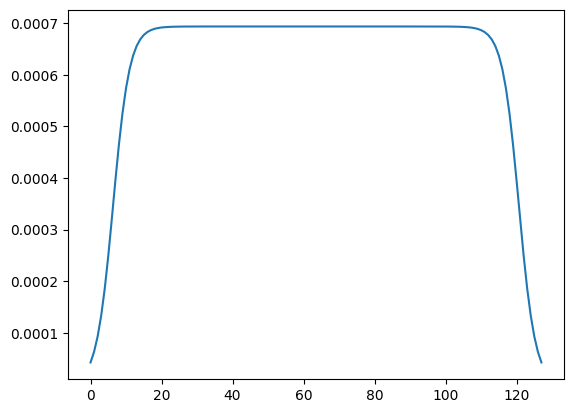

In [ ]:
plt.plot(mask[0,:])

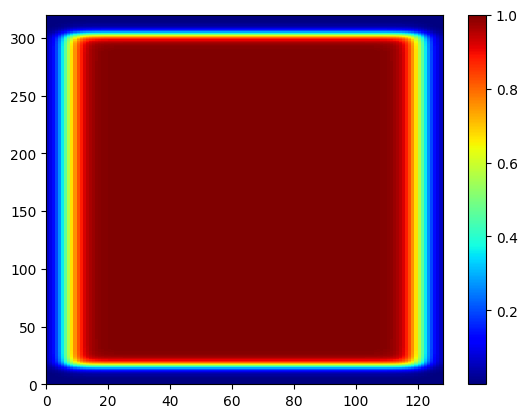

In [ ]:
plt.pcolor(mask, cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
train_inputs.shape

torch.Size([16, 1, 320, 128])

In [ ]:
maskT = (1+0)*0.5+0.5*(1-0)*\
        torch.tanh((train_inputs.detach()[0,0] - train_inputs.detach()[0,0].max()*0.01)/0.005)

In [ ]:
maxTtens=torch.max(torch.max(train_inputs, dim=-1).values, dim=-1).values
maxTtens=maxTtens.unsqueeze(-1).unsqueeze(-1).expand(16,1,320,128)
maskT = (1+0)*0.5+0.5*(1-0)*\
        torch.tanh((train_inputs - maxTtens*0.01)/0.005)

In [ ]:
maskT.shape

torch.Size([16, 1, 320, 128])

In [ ]:
#maskT = (1+0)*0.5+0.5*(1-0)*\
#        torch.tanh((train_inputs - \
#         (torch.max(torch.max(train_inputs, dim=-1).values, dim=-1).values).squeeze(-1)*0.01)/0.005)

In [ ]:
train_inputs.shape

torch.Size([16, 1, 320, 128])

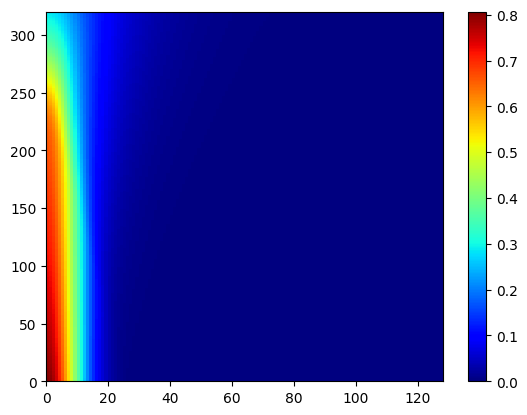

In [ ]:
plt.pcolor(train_inputs.detach()[0,0].cpu().numpy(), cmap='jet')
plt.colorbar()

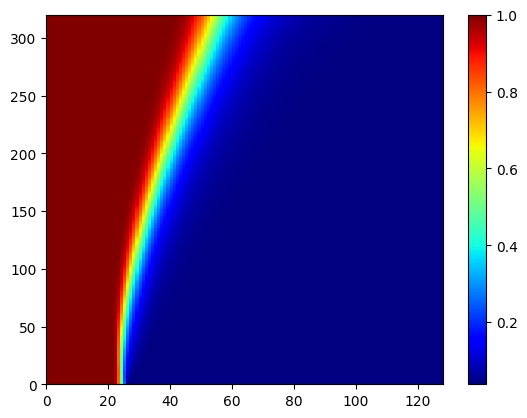

In [ ]:
plt.pcolor(maskT.detach().cpu().numpy()[0,0], cmap='jet')
plt.colorbar()

In [ ]:
mask.shape

torch.Size([320, 128])

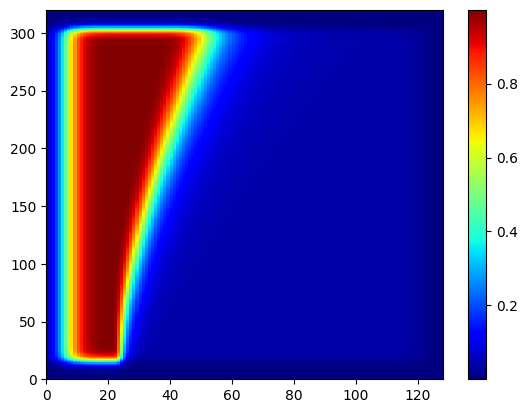

In [ ]:
plt.pcolor(mask*maskT.detach().cpu().numpy()[0,0], cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
def create_maskRZT(train_inputs):

  eps = 1e-6
  new_s = train_inputs.shape[0], 1, train_inputs.shape[2], train_inputs.shape[3]

  r = torch.linspace(rmin+eps, rmax, M) / l
  z = torch.linspace(zmin, zmax, N) / l

  r, z = torch.meshgrid(r, z, indexing='xy')

  mask1 = (1-0)/2+ (1+0)/2*np.tanh((r*1-r.max()*0.05)/0.5)
  mask2 = (1-0)/2+ (1+0)/2*np.tanh(-(r*1-r.max()*0.95)/0.5)
  mask3= (1-0)/2+ (1+0)/2*np.tanh((z*1-z.max()*0.05)/0.5)
  mask4 = (1-0)/2+ (1+0)/2*np.tanh(-(z*1-z.max()*0.95)/0.5)
  mask = mask1*mask2*mask3*mask4
  maskRZ = mask.unsqueeze(0).unsqueeze(0).expand(new_s).to(device)
  maxTtens=torch.max(torch.max(train_inputs, dim=-1).values, dim=-1).values
  maxTtens=maxTtens.unsqueeze(-1).unsqueeze(-1).expand(new_s)
  maskT = (1+0)*0.5+0.5*(1-0)*\
        torch.tanh((train_inputs - maxTtens*0.01)/0.005)

  maskRZT = maskRZ * maskT

  return maskRZT

In [ ]:
maskRZT = create_maskRZT(train_inputs)

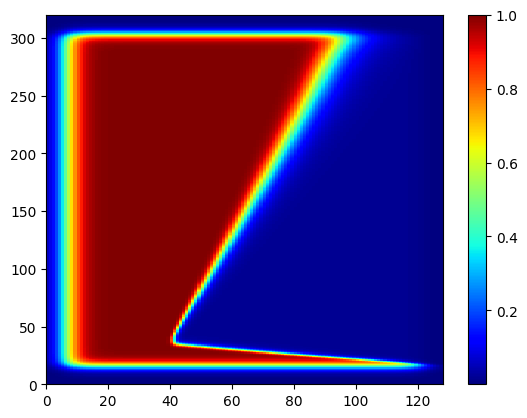

In [ ]:
plt.pcolor(maskRZT[1,0].cpu(), cmap='jet')
plt.colorbar()
plt.show()

# Turn on the physics loss (residuals from equations). Training

In [ ]:
from torch.nn import MSELoss
from lightning.pytorch.callbacks import ModelCheckpoint

class Lit_test2(L.LightningModule):
    def __init__(self, model, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.model = model
        self.metricL1 = nn.L1Loss()
        self.metricL2 = torch.nn.MSELoss()
        self.train_acc = Metrics_ac()
        self.lamb=1
        self.lr=lr

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(),
                                lr=self.lr,weight_decay=0)
        return optimizer

    def training_step(self, batch, batch_idx):

        train_inputs = batch[:, 2,:,:].unsqueeze(1)
        mask = (torch.abs(train_inputs[:,0]) >= torch.abs(train_inputs[:,0]).max()*0).unsqueeze(1)

        train_outputs = self.model(train_inputs)

        maskRZT = create_maskRZT(train_inputs)

        loss_data_vr = self.metricL1(train_outputs[:,0], batch[:,0])
        loss_data_vz = self.metricL1(train_outputs[:,1], batch[:,1])
        loss_data_T = self.metricL1(train_outputs[:,2], batch[:,2])
        loss_data_p = self.metricL1(train_outputs[:,3], batch[:,3])
        loss_data_muT = self.metricL1(train_outputs[:,4], batch[:,4])

        pde_T = train_outputs[:, 2,:,:].unsqueeze(1)

        f1 = pde_f1(train_outputs, pde_T) * maskRZT
        f2 = pde_f2(train_outputs, pde_T) * maskRZT
        f3 = pde_f3(train_outputs, pde_T) * maskRZT
        f4 = pde_f4(train_outputs, pde_T) * maskRZT

        f1_sim = pde_f1(batch, train_inputs) * maskRZT
        f2_sim = pde_f2(batch, train_inputs) * maskRZT
        f3_sim = pde_f3(batch, train_inputs) * maskRZT
        f4_sim = pde_f4(batch, train_inputs) * maskRZT

        loss_pde1 =  self.metricL2(f1, torch.zeros_like(f1))
        loss_pde2 =  self.metricL2(f2, torch.zeros_like(f2))
        loss_pde3 =  self.metricL2(f3, torch.zeros_like(f3))
        loss_pde4 =  self.metricL2(f4, torch.zeros_like(f4))

        #BC
        loss_inlet = loss_inlet_f(self.metricL2, train_outputs,batch)
        loss_axis = loss_axis_f(self.metricL2, train_outputs,batch)
        loss_outlet = loss_outlet_f(self.metricL2, train_outputs,batch)
        loss_free = loss_free_f(self.metricL2, train_outputs,batch)

        loss_ders_vr = loss_derivatives(train_outputs[:,0].unsqueeze(1),
                                        batch[:,0].unsqueeze(1),
                                        self.metricL2)
        loss_ders_vz = loss_derivatives(train_outputs[:,1].unsqueeze(1),
                                        batch[:,1].unsqueeze(1),
                                        self.metricL2)
        loss_ders_T = loss_derivatives(train_outputs[:,2].unsqueeze(1),
                                       batch[:,2].unsqueeze(1),
                                       self.metricL2)
        loss_ders_p = loss_derivatives(train_outputs[:,3].unsqueeze(1),
                                       batch[:,3].unsqueeze(1),
                                       self.metricL2)
        loss_ders_mu = loss_derivatives(train_outputs[:,4].unsqueeze(1),
                                        batch[:,4].unsqueeze(1),
                                        self.metricL2)
        loss_ders_vr_smooth = loss_derivatives_smooth(train_outputs[:,0].unsqueeze(1),
                                        self.metricL2)
        loss_ders_vz_smooth = loss_derivatives_smooth(train_outputs[:,1].unsqueeze(1),
                                        self.metricL2)
        loss_ders_p_smooth = loss_derivatives_smooth(train_outputs[:,3].unsqueeze(1),
                                        self.metricL2)
        loss_ders_mu_smooth = loss_derivatives_smooth(train_outputs[:,4].unsqueeze(1),
                                        self.metricL2)

        loss=     1e-0*(loss_ders_vr_smooth+loss_ders_vz_smooth+loss_ders_p_smooth+loss_ders_mu_smooth)+\
                  1e-0*(loss_ders_vr+loss_ders_vz+loss_ders_T+loss_ders_p+loss_ders_mu+\
                  loss_data_vr+\
                  loss_data_vz+\
                  loss_data_p+\
                  loss_data_muT)*1e0+\
                  loss_data_T+\
                  (loss_pde1*1e5+\
                  loss_pde2*1e2+\
                  loss_pde3*1e7+\
                  loss_pde4*1e4)*1e-0+\
                  (loss_inlet+\
                  loss_axis+\
                  loss_outlet+\
                  loss_free)*1e-10

        metrics = {'loss_data_vr': loss_data_vr,
                   'loss_data_vz': loss_data_vz,
                   'loss_data_T': loss_data_T,
                   'loss_data_p': loss_data_p,
                   'loss_data_muT': loss_data_muT,
                   'loss_pde1': loss_pde1,
                   'loss_pde2': loss_pde2,
                   'loss_pde3': loss_pde3,
                   'loss_pde4': loss_pde4,
                   'loss_inlet':loss_inlet,
                   'loss_axis':loss_axis,
                   'loss_outlet':loss_outlet,
                   'loss_free':loss_free,
                   'loss_ders_vr': loss_ders_vr,
                   'loss_ders_T': loss_ders_T,
                   'loss_ders_vz': loss_ders_vz,
                   'loss_ders_p': loss_ders_p,
                   'loss_ders_mu': loss_ders_mu,
                   'loss_ders_vr_smooth': loss_ders_vr_smooth,
                   'loss_ders_vz_smooth': loss_ders_vz_smooth,
                   'loss_ders_p_smooth': loss_ders_p_smooth,
                   'loss_ders_mu_smooth': loss_ders_mu_smooth,
                   'loss': loss
                   }

        acc_metrics = dict()

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,0].unsqueeze(1), batch[:,0].unsqueeze(1))
        acc_metrics['vr_mean'], acc_metrics['vr_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,1].unsqueeze(1), batch[:,1].unsqueeze(1))
        acc_metrics['vz_mean'], acc_metrics['vz_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,2].unsqueeze(1), batch[:,2].unsqueeze(1))
        acc_metrics['T_mean'], acc_metrics['T_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,2].unsqueeze(1), batch[:,3].unsqueeze(1))
        acc_metrics['p_mean'], acc_metrics['p_max'] = mean_m, max_m

        mean_m, max_m= self.train_acc.calculate(train_outputs[:,3].unsqueeze(1), batch[:,4].unsqueeze(1))
        acc_metrics['muT_mean'], acc_metrics['muT_max'] = mean_m, max_m

        wandb.log(metrics)
        wandb.log(acc_metrics)

        self.log('loss', loss)

        return loss

    def validation_step(self, batch, batch_idx):
        pass


    def on_train_epoch_end(self):
        pass


    def on_validation_epoch_end(self):
        pass

    def forward(self, x):
      return self.model(x)


In [ ]:
wandb.init(
        settings=wandb.Settings(start_method="thread"),
        project="DAE_PDE_simple_AE_v1",
        config={
            "lr": 1e-3,
            "comment": 'latent dim=4, only data'
            })

T_max,▁▂▁▁▁▁▂▃▁█▁▂▁▁▁▁▁▂▁▂▂▂▂▁▁▁▁▁▁▂▂▂▁▁▂▁▂▁▁▁
T_mean,▂▁▁▁▁▁▁▃▁█▁▂▂▁▁▁▁▂▁▁▂▁▂▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁
loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_axis,▅▇▆▆▃▅▅▃▄█▄▅▅▂▄▃▄▅▄▃▁▃▁▁▃▄▃▃▂█▅▆▆▄▅▆▄▄▃▄
loss_data_T,▅▆█▆▄▆▇▄▄▆▆▇▃▃▄▅▄▄▅▃▁▃▂▁▂▃▃▄▂█▅▇▇▅▅▆▅▆▆▅
loss_data_muT,▁▅▅▄▅▅▄▆▆▄▅▇▄▅▆▅▄▄▆▅█▄▆▃▆▄▄▆▅▃▄▄▅▅▄▄▅▄▄▅
loss_data_p,▁▅▂▂▃▃▂▆▅▁▃▅▃▅▆▅▃▄▅▄█▃▄▂▄▄▃▅▄▃▅▅▅▃▃▃▄▃▂▄
loss_data_vr,▃▇▆▅▅▆▃█▇▅▅▆▄▆▇▆▅▅▆▅▇▃▆▂▅▃▄▆▄▂▁▇▇▅▅▅▅▄▄▅
loss_data_vz,▃▄▂▂▃▃▂▅▄▁▃▅▂▄▆▄▃▃▅▄█▃▄▃▅▄▄▆▅▆▄▄▂▂▂▂▃▂▂▄
loss_ders_T,▁▆▅▆▆▆▇▇▇█▆▅▆▅▅▅▄▅▅▄▃▄▄▂▄▃▄▄▃▆▆▅▆▆▆▇▇▆▅▅
loss_ders_mu,▁▅▄▄▅▅▄█▆▃▅▅▄▅▇▅▄▅▅▄▇▃▅▃▄▄▃▅▄▄▅▅▅▄▅▄▄▄▃▅


In [ ]:
path='/content/ld=4/simpleDAE-epoch=94-val_loss=0.00-v1.ckpt'
#modelTest = simpleAE(latent_dim=4)
#lt = Lit_test1(modelTest)
lit_model_2 = Lit_test2.load_from_checkpoint(checkpoint_path=path)

#model.eval()

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [ ]:
num_epochs = 10
L.seed_everything(42)

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename='simpleDAE-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    verbose=True,
    monitor="loss",
    mode="min")

trainer_u = L.Trainer(max_epochs=num_epochs,
                      callbacks=[checkpoint_callback])

trainer_u.fit(model=lit_model_2, train_dataloaders=train_loader)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /content/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 20: 'loss' reached 303.64694 (best 303.64694), saving model to '/content/checkpoints/simpleDAE-epoch=00-val_loss=0.00.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 20: 'loss' reached 303.64694 (best 303.64694), saving model to '/content/checkpoints/simpleDAE-epoch=00-val_loss=0.00.ckpt' as top 1
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
INFO: Epoch 1, global step 40: 'loss' reached 45.75480 (best 45.75480), saving model to '/content/checkpoints/simpleDAE-epoch=01-val_loss=0.00-v1.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 40: 'loss' reached 45.75480 (best 45.75480), saving model to '/content/checkpoints/simpleDAE-epoch=01-val_loss=0.00-v1.ckpt' as top 1
INFO: Epoch 2, global step 60: 'loss' reached 6.4116

In [ ]:
filename='simple_dae_model_w_ld=4_best.pt'
torch.save(model.state_dict(), filename)
filescolab.download(filename)

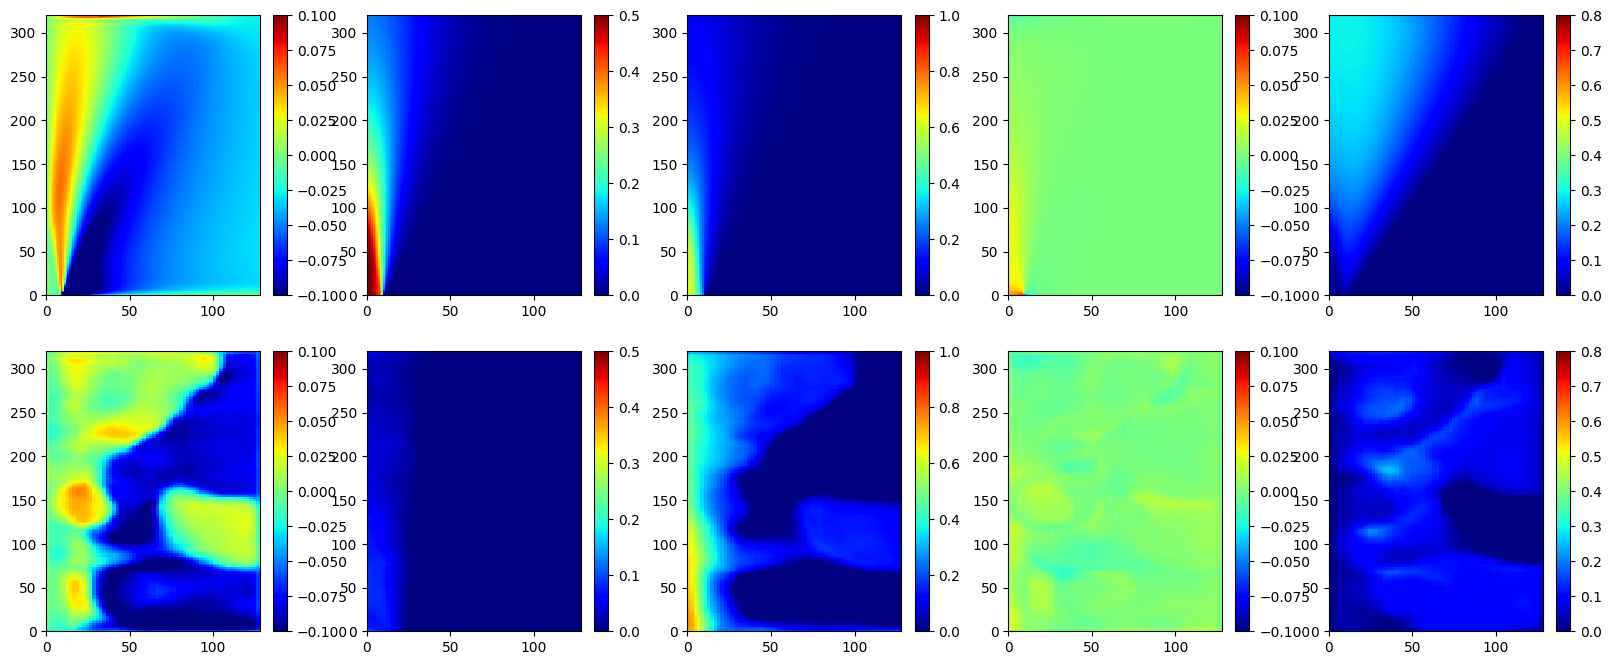

In [ ]:
im = next(iter(train_loader))

train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
#model = lit_model.to(device)
lit_model_2.to(device)
out = lit_model_2(train_inputs)

idx=1

cax = [(-0.1, 0.1), (0, 0.5), (0, 1), (-0.1, 0.1), (0, 0.8)]
fig, ax = plt.subplots(2, 5, figsize=(20, 8))

for i in range(5):
  im_tar = ax[0, i].pcolor(im[idx,i].detach().cpu().numpy(), cmap='jet', vmin=cax[i][0], vmax=cax[i][1])
  plt.colorbar(im_tar, ax=ax[0, i])

  im_pred = ax[1, i].pcolor(out[idx,i].detach().cpu().numpy(), cmap='jet', vmin=cax[i][0], vmax=cax[i][1])
  plt.colorbar(im_pred, ax=ax[1, i])

plt.show()

## Inlet


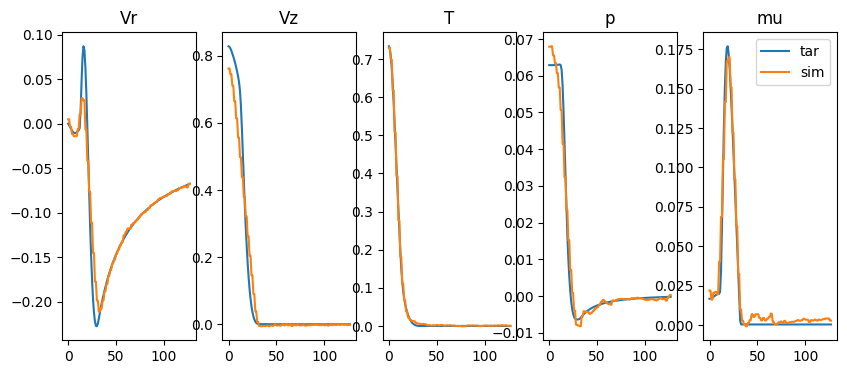

In [ ]:
im = next(iter(train_loader))

train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
#lit_model = lit_model.to(device)
out = lit_model_best(train_inputs)
titles = ['Vr', 'Vz','T','p','mu']
idx=5

fig, ax = plt.subplots(1, 5, figsize=(10, 4))

for i in range(5):
  im_tar = ax[i].plot(im[idx,i,50,:].detach().cpu().numpy(), label='tar')
  ax[i].set_title(titles[i])
  im_pred = ax[i].plot(out[idx,i,50,:].detach().cpu().numpy(), label='sim')

plt.legend()

plt.show()

## Axis

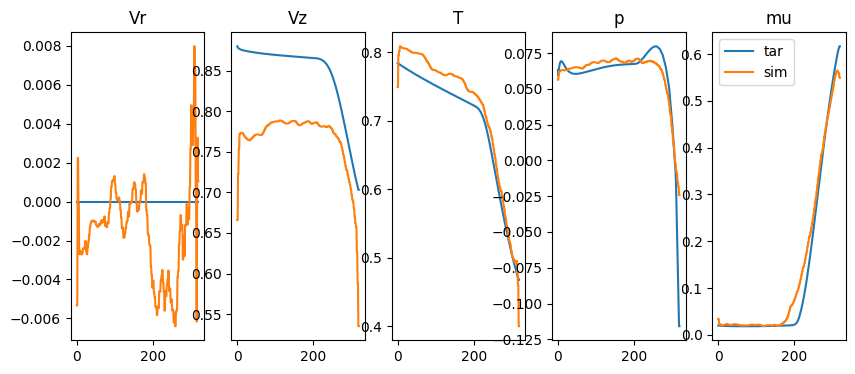

In [ ]:
im = next(iter(train_loader))

train_inputs = im[:, 2,:,:].unsqueeze(1)
train_inputs = train_inputs.to(device)
#lit_model = lit_model.to(device)
out = lit_model_best(train_inputs)
titles = ['Vr', 'Vz','T','p','mu']
idx=5

fig, ax = plt.subplots(1, 5, figsize=(10, 4))

for i in range(5):
  im_tar = ax[i].plot(im[idx,i,:,0].detach().cpu().numpy(), label='tar')
  ax[i].set_title(titles[i])
  im_pred = ax[i].plot(out[idx,i,:,0].detach().cpu().numpy(), label='sim')

plt.legend()

plt.show()